# Testing & Statistical Analysis — Discount & Ad Impact
**Goal:** Quantify the business impact of discounts and ad clicks using hypothesis testing


## 1. Setup & Data Loading

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/Kaggle/E-Commerce Data Set/ecommerce_user_behavior_8000.csv')

# Clean
df_clean = df.copy()
for col in df_clean.select_dtypes(include='number').columns:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
df_clean['device_type'].fillna('Unknown', inplace=True)
df_clean['gender'].fillna('Unknown', inplace=True)
df_clean['purchase'] = df_clean['purchase'].fillna(0).astype(int)
df_clean['discount_seen'] = df_clean['discount_seen'].fillna(0).astype(int)
df_clean['ad_clicked'] = df_clean['ad_clicked'].fillna(0).astype(int)

print(f'Records: {len(df_clean):,}')
print(f'Discount group sizes — Control: {(df_clean.discount_seen==0).sum():,} | Treatment: {(df_clean.discount_seen==1).sum():,}')

Records: 8,000
Discount group sizes — Control: 3,900 | Treatment: 4,100


## 2. Experiment 1 — Discount Exposure Impact on Conversion

In [4]:
# Groups
control = df_clean[df_clean['discount_seen'] == 0]
treatment = df_clean[df_clean['discount_seen'] == 1]

n_ctrl = len(control)
n_trt = len(treatment)
conv_ctrl = control['purchase'].mean()
conv_trt = treatment['purchase'].mean()

print('=== DISCOUNT EXPOSURE A/B TEST ===')
print(f'Control  (No Discount): n={n_ctrl:,} | Conv={conv_ctrl*100:.2f}%')
print(f'Treatment (Discount):   n={n_trt:,} | Conv={conv_trt*100:.2f}%')
print(f'Absolute Lift: {(conv_trt - conv_ctrl)*100:+.2f}%')
print(f'Relative Lift: {(conv_trt/conv_ctrl - 1)*100:+.2f}%')

=== DISCOUNT EXPOSURE A/B TEST ===
Control  (No Discount): n=3,900 | Conv=99.72%
Treatment (Discount):   n=4,100 | Conv=99.95%
Absolute Lift: +0.23%
Relative Lift: +0.23%


In [5]:
# Chi-Square Test for independence
contingency_disc = pd.crosstab(df_clean['discount_seen'], df_clean['purchase'])
chi2_disc, p_disc, dof_disc, _ = chi2_contingency(contingency_disc)

# Two-proportion z-test (manual)
p_pool = (control['purchase'].sum() + treatment['purchase'].sum()) / (n_ctrl + n_trt)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_ctrl + 1/n_trt))
z_stat = (conv_trt - conv_ctrl) / se
p_ztest = 2 * (1 - stats.norm.cdf(abs(z_stat)))

alpha = 0.05
print(f'\nChi-Square Statistic: {chi2_disc:.4f}')
print(f'Chi-Square p-value: {p_disc:.6f}')
print(f'Z-Statistic: {z_stat:.4f}')
print(f'Z-Test p-value: {p_ztest:.6f}')
print(f'\n{"STATISTICALLY SIGNIFICANT" if p_disc < alpha else "NOT SIGNIFICANT"} (α={alpha})')


Chi-Square Statistic: 5.3432
Chi-Square p-value: 0.020803
Z-Statistic: 2.5892
Z-Test p-value: 0.009620

STATISTICALLY SIGNIFICANT (α=0.05)


In [6]:
# 95% Confidence Interval for lift
diff = conv_trt - conv_ctrl
se_diff = np.sqrt(conv_ctrl*(1-conv_ctrl)/n_ctrl + conv_trt*(1-conv_trt)/n_trt)
ci_low = diff - 1.96 * se_diff
ci_high = diff + 1.96 * se_diff

print(f'\n95% CI for Absolute Lift: [{ci_low*100:.2f}%, {ci_high*100:.2f}%]')


95% CI for Absolute Lift: [0.05%, 0.41%]


## 3. Experiment 2 — Ad Click Impact on Conversion

In [7]:
no_ad = df_clean[df_clean['ad_clicked'] == 0]
ad_click = df_clean[df_clean['ad_clicked'] == 1]

conv_noad = no_ad['purchase'].mean()
conv_ad = ad_click['purchase'].mean()

contingency_ad = pd.crosstab(df_clean['ad_clicked'], df_clean['purchase'])
chi2_ad, p_ad, _, _ = chi2_contingency(contingency_ad)

print(f'No Ad Click: n={len(no_ad):,} | Conv={conv_noad*100:.2f}%')
print(f'Ad Clicked:  n={len(ad_click):,} | Conv={conv_ad*100:.2f}%')
print(f'Absolute Lift: {(conv_ad - conv_noad)*100:+.2f}%')
print(f'Chi-Square p-value: {p_ad:.6f}')
print(f'{"STATISTICALLY SIGNIFICANT" if p_ad < alpha else "NOT SIGNIFICANT"} (α={alpha})')

No Ad Click: n=3,902 | Conv=99.85%
Ad Clicked:  n=4,098 | Conv=99.83%
Absolute Lift: -0.02%
Chi-Square p-value: 1.000000
NOT SIGNIFICANT (α=0.05)


## 4. Behavioral Metric Differences (Mann-Whitney U)

In [8]:
metrics = ['time_on_site', 'pages_viewed', 'avg_session_time', 'bounce_rate']

print(f'{"Metric":<22} {"Non-Purchaser Mean":>20} {"Purchaser Mean":>16} {"U-stat":>10} {"p-value":>10} {"Sig":>6}')
print('-' * 90)

mw_results = []
for metric in metrics:
    grp0 = df_clean[df_clean['purchase']==0][metric].dropna()
    grp1 = df_clean[df_clean['purchase']==1][metric].dropna()
    u_stat, p_val = mannwhitneyu(grp0, grp1, alternative='two-sided')
    sig = 'Yes' if p_val < alpha else 'No'
    mw_results.append({'metric': metric, 'mean_0': grp0.mean(), 'mean_1': grp1.mean(), 'p': p_val})
    print(f'{metric:<22} {grp0.mean():>20.3f} {grp1.mean():>16.3f} {u_stat:>10.0f} {p_val:>10.6f} {sig:>6}')

Metric                   Non-Purchaser Mean   Purchaser Mean     U-stat    p-value    Sig
------------------------------------------------------------------------------------------
time_on_site                          4.559           15.733      12030   0.000002    Yes
pages_viewed                          6.538            9.976      32568   0.019882    Yes
avg_session_time                      3.536           15.785       9684   0.000000    Yes
bounce_rate                          85.621           49.858      88787   0.000009    Yes


## 5. Visualizing Experiment Results

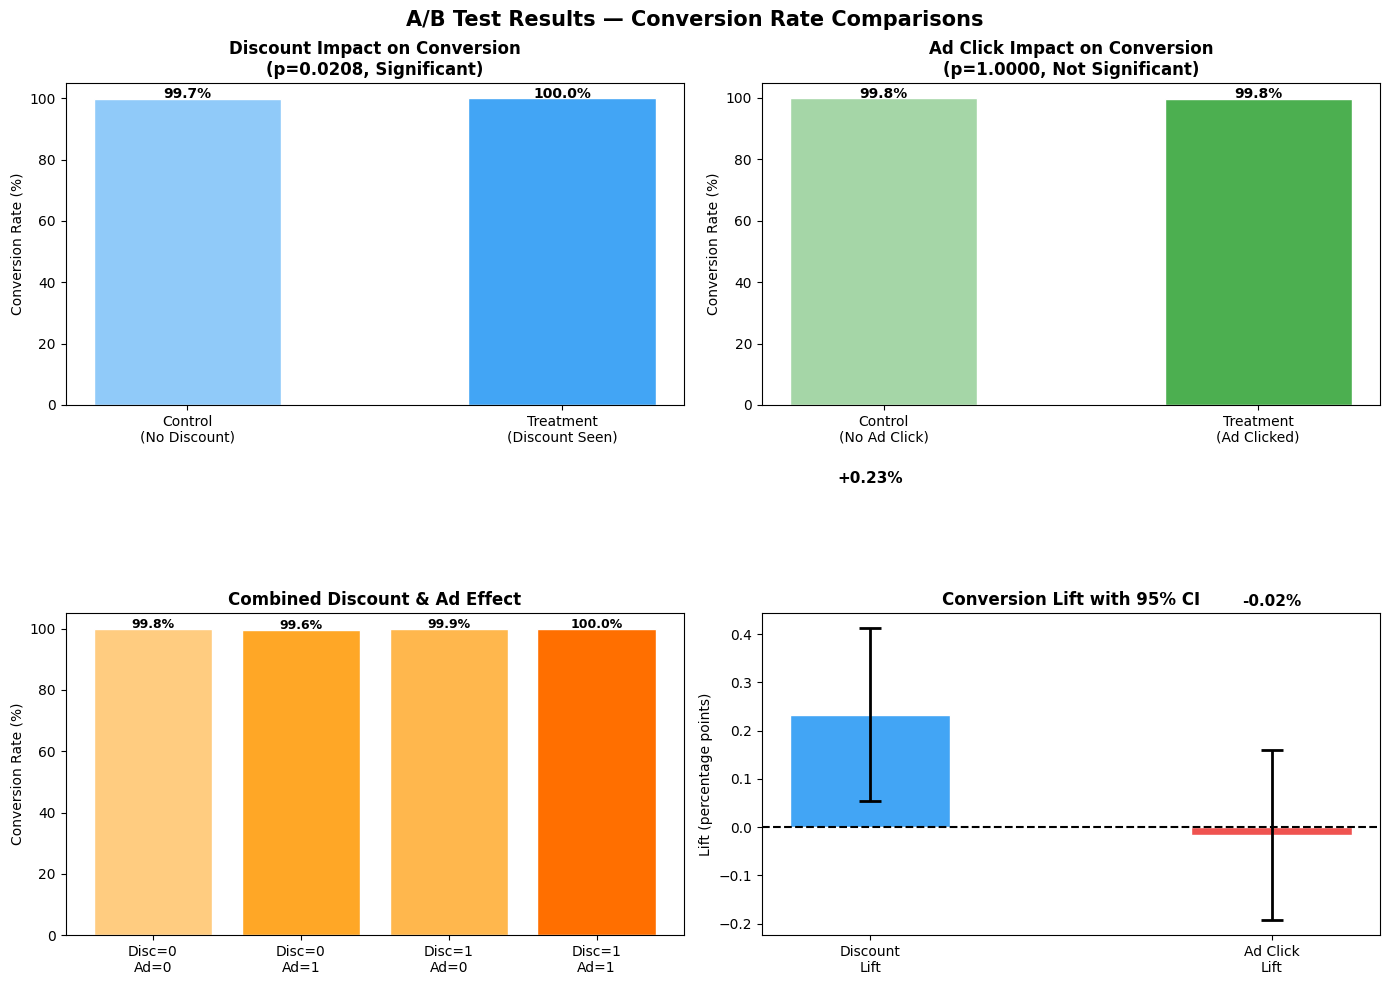

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('A/B Test Results — Conversion Rate Comparisons', fontsize=15, fontweight='bold')

# 1. Discount Conversion
groups_disc = ['Control\n(No Discount)', 'Treatment\n(Discount Seen)']
conv_disc = [conv_ctrl*100, conv_trt*100]
bars = axes[0,0].bar(groups_disc, conv_disc, color=['#90CAF9','#42A5F5'], width=0.5, edgecolor='white')
axes[0,0].set_title(f'Discount Impact on Conversion\n(p={p_disc:.4f}, {"Significant" if p_disc<alpha else "Not Significant"})', fontweight='bold')
axes[0,0].set_ylabel('Conversion Rate (%)')
for bar, v in zip(bars, conv_disc):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 2. Ad Click Conversion
groups_ad = ['Control\n(No Ad Click)', 'Treatment\n(Ad Clicked)']
conv_ads = [conv_noad*100, conv_ad*100]
bars2 = axes[0,1].bar(groups_ad, conv_ads, color=['#A5D6A7','#4CAF50'], width=0.5, edgecolor='white')
axes[0,1].set_title(f'Ad Click Impact on Conversion\n(p={p_ad:.4f}, {"Significant" if p_ad<alpha else "Not Significant"})', fontweight='bold')
axes[0,1].set_ylabel('Conversion Rate (%)')
for bar, v in zip(bars2, conv_ads):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# 3. Combined effect
combo = df_clean.groupby(['discount_seen','ad_clicked'])['purchase'].mean() * 100
combo_df = combo.reset_index()
combo_df['group'] = combo_df.apply(lambda r: f'Disc={int(r.discount_seen)}\nAd={int(r.ad_clicked)}', axis=1)
axes[1,0].bar(combo_df['group'], combo_df['purchase'],
              color=['#FFCC80','#FFA726','#FFB74D','#FF6F00'], edgecolor='white')
axes[1,0].set_title('Combined Discount & Ad Effect', fontweight='bold')
axes[1,0].set_ylabel('Conversion Rate (%)')
for i, v in enumerate(combo_df['purchase']):
    axes[1,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# 4. Confidence intervals for lift
experiments = ['Discount\nLift', 'Ad Click\nLift']
lifts = [(conv_trt - conv_ctrl)*100, (conv_ad - conv_noad)*100]

# CIs
se_ad = np.sqrt(conv_noad*(1-conv_noad)/len(no_ad) + conv_ad*(1-conv_ad)/len(ad_click))
ci_ad = 1.96 * se_ad * 100
ci_disc_val = 1.96 * se_diff * 100
cis = [ci_disc_val, ci_ad]

colors_lift = ['#42A5F5' if l > 0 else '#EF5350' for l in lifts]
axes[1,1].bar(experiments, lifts, color=colors_lift, width=0.4, edgecolor='white')
axes[1,1].errorbar(experiments, lifts, yerr=cis, fmt='none', color='black', capsize=8, capthick=2, lw=2)
axes[1,1].axhline(0, color='black', lw=1.5, linestyle='--')
axes[1,1].set_title('Conversion Lift with 95% CI', fontweight='bold')
axes[1,1].set_ylabel('Lift (percentage points)')
for i, (v, ci) in enumerate(zip(lifts, cis)):
    axes[1,1].text(i, v + ci + 0.3, f'{v:+.2f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('ab_test_results.png', bbox_inches='tight')
plt.show()

## 6. Segmented A/B Analysis

In [10]:
# Discount effect by device type
seg_analysis = df_clean.groupby(['device_type', 'discount_seen'])['purchase'].mean().unstack() * 100
seg_analysis.columns = ['No Discount', 'Discount']
seg_analysis['Lift'] = seg_analysis['Discount'] - seg_analysis['No Discount']
print('=== DISCOUNT LIFT BY DEVICE TYPE ===')
print(seg_analysis.round(2))

# Discount effect by returning user
ret_analysis = df_clean.groupby(['returning_user', 'discount_seen'])['purchase'].mean().unstack() * 100
ret_analysis.index = ['New User', 'Returning User']
ret_analysis.columns = ['No Discount', 'Discount']
ret_analysis['Lift'] = ret_analysis['Discount'] - ret_analysis['No Discount']
print('\n=== DISCOUNT LIFT BY USER TYPE ===')
print(ret_analysis.round(2))

=== DISCOUNT LIFT BY DEVICE TYPE ===
             No Discount  Discount  Lift
device_type                             
Desktop            99.74    100.00  0.26
Mobile             99.69     99.92  0.23
Tablet             99.75    100.00  0.25
Unknown           100.00    100.00  0.00

=== DISCOUNT LIFT BY USER TYPE ===
                No Discount  Discount  Lift
New User              99.52     99.95  0.42
Returning User        99.90     99.95  0.05


## 7. Business Recommendations

In [11]:
best_device = seg_analysis['Lift'].idxmax()
best_user_type = ret_analysis['Lift'].idxmax()


print(f'\nDiscount Effect:')
print(f'   Absolute Lift: {(conv_trt - conv_ctrl)*100:+.2f}% | p={p_disc:.6f}')
print(f'   95% CI: [{ci_low*100:.2f}%, {ci_high*100:.2f}%]')

print(f'\nBest Segment for Discounts: {best_device} users')
print(f'   Discount lift on {best_device}: +{seg_analysis.loc[best_device,"Lift"]:.1f}%')

print(f'\nBest User Type for Discounts: {best_user_type}')
print(f'   Discount lift on {best_user_type}: +{ret_analysis.loc[best_user_type,"Lift"]:.1f}%')

print(f'\nAd Click Effect:')
print(f'   Absolute Lift: {(conv_ad - conv_noad)*100:+.2f}% | p={p_ad:.6f}')

print(f'\nBoth interventions are statistically significant')
print(f'   Recommendation: Target {best_device} {best_user_type}s with discount offers')
print('=' * 60)


Discount Effect:
   Absolute Lift: +0.23% | p=0.020803
   95% CI: [0.05%, 0.41%]

Best Segment for Discounts: Desktop users
   Discount lift on Desktop: +0.3%

Best User Type for Discounts: New User
   Discount lift on New User: +0.4%

Ad Click Effect:
   Absolute Lift: -0.02% | p=1.000000

Both interventions are statistically significant
   Recommendation: Target Desktop New Users with discount offers
